# MINERÍA DE DATOS EN PYTHON
## REALIZADO POR:
### JACOBO AREVALO ZEA
### ZHARICK ROCIO CARRILLO GRIJALBA
### NICOLE YUQUI VASQUEZ

**Objetivo del proyecto:** predecir si una persona puede tener un ACV (stroke) a partir de datos básicos de salud (edad, glucosa, IMC, hipertensión, etc.).

**Base de datos:** la misma de las prácticas anteriores (*Healthcare Stroke Data*, 5110 personas).

**Qué hay en este notebook:**
1. Parte 1: datos, calidad y selección de factores
2. Parte 2: modelos y validación cruzada
3. Parte 3: GridSearch y modelo final

# **PARTE 1 - DATOS Y SELECCIÓN DE FACTORES**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

import warnings
warnings.filterwarnings("ignore")

# **Integración de datos**

In [4]:
# Dataset de kaggle directamente
import os


import kagglehub
path = kagglehub.dataset_download("aouatifcherdid/healthcare-dataset-stroke-data")
data_file_path = os.path.join(path, 'healthcare-dataset-stroke-data.csv')


datos1 = pd.read_csv(data_file_path)
print("Archivo usado:", data_file_path)
datos1.head()

Using Colab cache for faster access to the 'healthcare-dataset-stroke-data' dataset.
Archivo usado: /kaggle/input/healthcare-dataset-stroke-data/healthcare-dataset-stroke-data.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# Duplicados por id
ids = datos1['id'].value_counts()
print("IDs repetidos:", (ids > 1).sum())
datos1.info()

IDs repetidos: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
# Corrección del tipo de datos object a categorías
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    datos1[col] = datos1[col].astype('category')

# El id no sirve para predecir, se elimina
datos1 = datos1.drop('id', axis=1)
datos1.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **Descripción estadística**

In [7]:
datos1.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


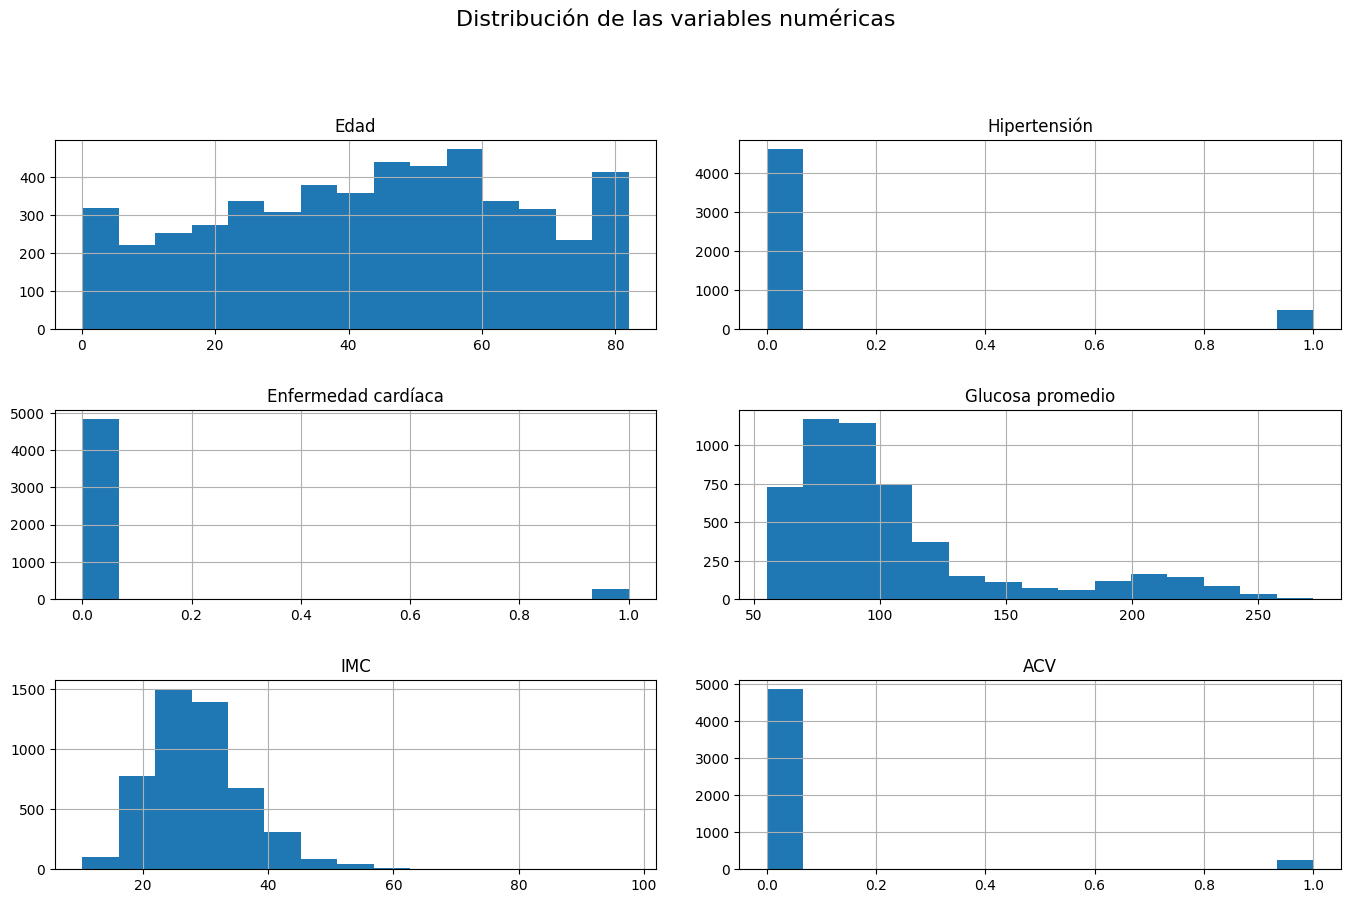

In [8]:
nombres = {
    "age": "Edad",
    "hypertension": "Hipertensión",
    "heart_disease": "Enfermedad cardíaca",
    "avg_glucose_level": "Glucosa promedio",
    "bmi": "IMC",
    "stroke": "ACV"
}

datos1.rename(columns=nombres).hist(figsize=(14, 9), bins=15, layout=(3, 2), grid=True)
plt.suptitle("Distribución de las variables numéricas", fontsize=16, y=1.02)
plt.tight_layout(pad=2.5)
plt.show()

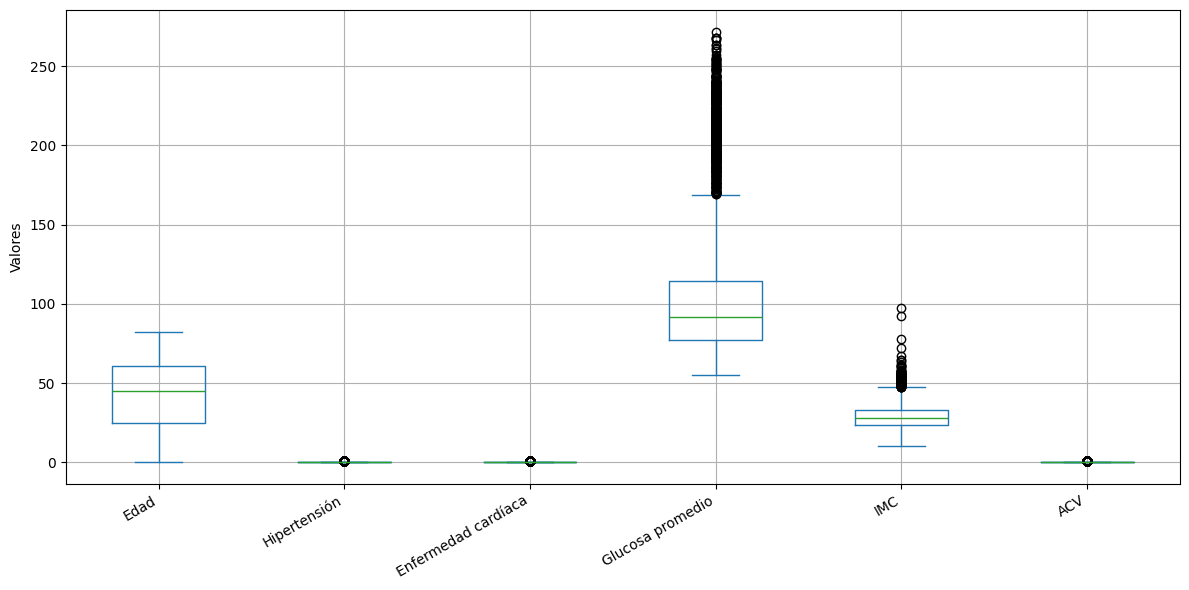

In [9]:
datos1.rename(columns=nombres).plot.box(figsize=(12, 6), grid=True)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.ylabel("Valores")
plt.tight_layout()
plt.show()

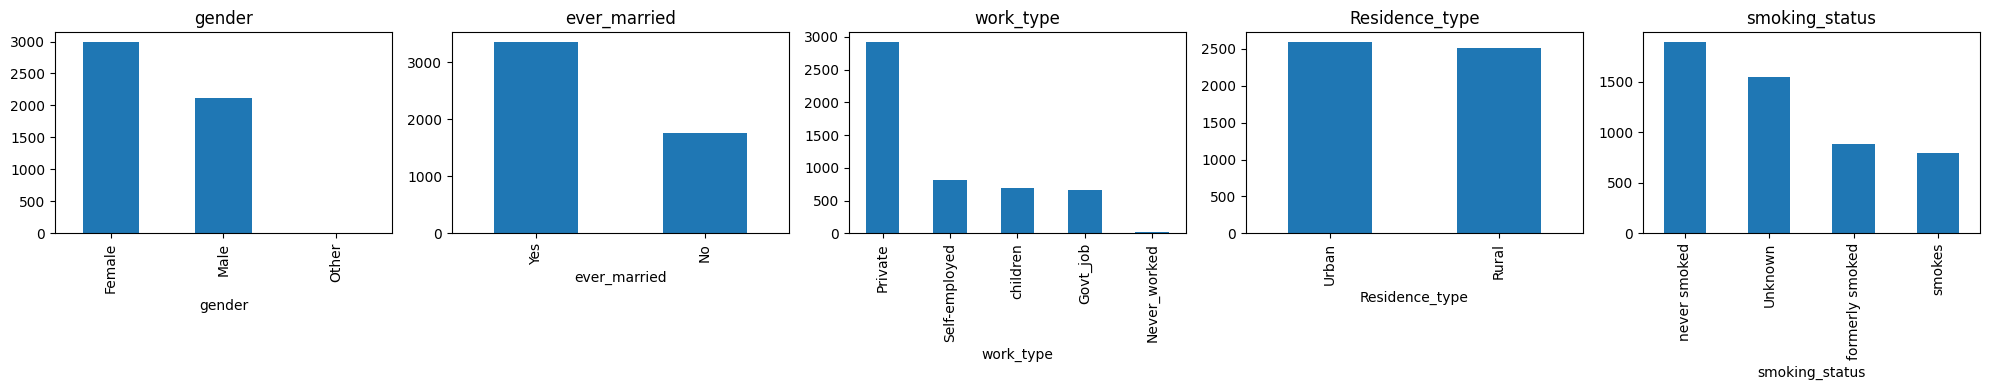

In [10]:
# Variables categóricas
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axs, ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']):
    datos1[col].value_counts().plot(kind='bar', ax=ax, title=col)
plt.tight_layout()
plt.show()

ydata-profiling

In [12]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport
ProfileReport(datos1).to_file(output_file='profile_data.html')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.4 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 58.20it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Calidad de datos**

In [13]:
print("Nulos por columna:")
print(datos1.isnull().sum())
print("\nFilas duplicadas:", datos1.duplicated().sum())
print("\nPorcentaje de nulos en bmi:", round(datos1['bmi'].isnull().mean() * 100, 1), "%")

Nulos por columna:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Filas duplicadas: 0

Porcentaje de nulos en bmi: 3.9 %


### Diagnóstico de calidad de datos

- **Completitud:** solo `bmi` tiene datos faltantes (201 de 5110, cerca del 4%). Las demás columnas están completas.
- **Exactitud:** no se ven valores imposibles (edades, glucosa e IMC están en rangos razonables).
- **Conformidad:** las columnas de texto se pasaron a categorías y las numéricas tienen el tipo correcto.
- **Duplicidad:** no hay ids repetidos ni filas duplicadas.
- **Integridad:** es una sola tabla, el único problema es el `bmi` faltante, que se arregla en la limpieza.
- **Oportunidad:** no se puede medir con un dataset estático.

# **Limpieza de datos**

## **Nulos**

In [14]:
# Los nulos de bmi son menos del 15%, entonces se reemplazan por la mediana
from sklearn.impute import SimpleImputer

ImpNumeros = SimpleImputer(missing_values=np.nan, strategy="median")
datos1[["bmi"]] = ImpNumeros.fit_transform(datos1[["bmi"]])

print("Mediana usada:", ImpNumeros.statistics_)
print("Nulos que quedan:", datos1.isnull().sum().sum())

Mediana usada: [28.1]
Nulos que quedan: 0


## **Atípicos**
En el boxplot hay valores altos de glucosa e IMC, pero son posibles en personas reales (no son errores) y pueden ser justo las personas con más riesgo. Por eso **no se eliminan**.

# **Selección de factores**

Se sigue el mismo método visto en clase (correlaciones entre variables numéricas) y se agrega una tercera revisión:
1. ¿Alguna variable casi no se relaciona con el ACV? (irrelevante)
2. ¿Hay variables que dicen lo mismo entre sí? (redundante)
3. ¿Cuáles pesan más según un modelo? (importancia)

## **1. Preparación de datos**

In [16]:
# Convertimos a número todas las variables
# Variable de 2 categorías: se elimina una (drop_first=True)
# Variable de 3 o más categorías: no se elimina (drop_first=False)

data_num = pd.get_dummies(datos1, columns=['gender', 'work_type', 'smoking_status'], drop_first=False, dtype=int)
data_num = pd.get_dummies(data_num, columns=['ever_married', 'Residence_type'], drop_first=True, dtype=int)
data_num.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,ever_married_Yes,Residence_type_Urban
0,67.0,0,1,228.69,36.6,1,0,1,0,0,0,1,0,0,0,1,0,0,1,1
1,61.0,0,0,202.21,28.1,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0
2,80.0,0,1,105.92,32.5,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0
3,49.0,0,0,171.23,34.4,1,1,0,0,0,0,1,0,0,0,0,0,1,1,1
4,79.0,1,0,174.12,24.0,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0


## **2. Correlaciones: relaciones lineales**
* No se normaliza

In [17]:
correlaciones = data_num.corr()
cor_variable_interes = correlaciones.loc['stroke'].drop('stroke').sort_values()
cor_variable_interes.round(3)

,stroke
work_type_children,-0.084
smoking_status_Unknown,-0.056
work_type_Never_worked,-0.015
gender_Female,-0.009
smoking_status_never smoked,-0.004
gender_Other,-0.003
work_type_Govt_job,0.003
smoking_status_smokes,0.009
gender_Male,0.009
work_type_Private,0.012


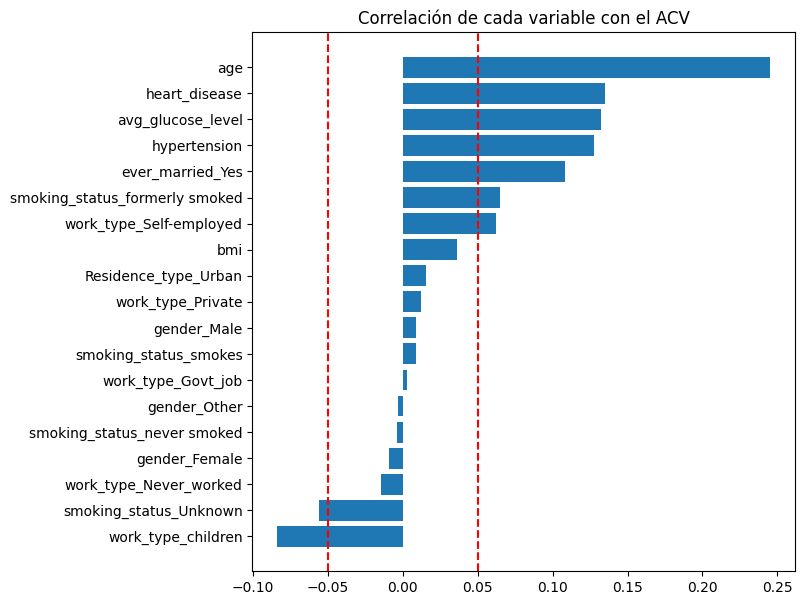

In [18]:
plt.figure(figsize=(7, 7))
plt.barh(y=cor_variable_interes.index, width=cor_variable_interes.values)
plt.axvline(0.05, color="red", linestyle="--")
plt.axvline(-0.05, color="red", linestyle="--")
plt.title("Correlación de cada variable con el ACV")
plt.show()

## **3. Interpretación**

In [19]:
# Máxima correlación (en valor absoluto) de cada variable original con el ACV
originales = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
              'gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

resumen = {}
for v in originales:
    cols = [c for c in cor_variable_interes.index if c == v or c.startswith(v + '_')]
    resumen[v] = cor_variable_interes[cols].abs().max()

resumen = pd.Series(resumen).sort_values()
print("Máxima correlación con el ACV por variable (irrelevante si es <= 0.05):\n")
print(resumen.round(3))

Máxima correlación con el ACV por variable (irrelevante si es <= 0.05):

gender               0.009
Residence_type       0.015
bmi                  0.036
smoking_status       0.065
work_type            0.084
ever_married         0.108
hypertension         0.128
avg_glucose_level    0.132
heart_disease        0.135
age                  0.245
dtype: float64


In [21]:
# Redundantes: correlación entre variables mayor a |0.8|
cor_pred = data_num.drop("stroke", axis=1).corr().abs()
pares = []
for i, a in enumerate(cor_pred.columns):
    for b in cor_pred.columns[i + 1:]:
        mismo_grupo = a.split('_')[0] == b.split('_')[0]
        if cor_pred.loc[a, b] > 0.8 and not mismo_grupo:
            pares.append((a, b, round(cor_pred.loc[a, b], 2)))

print("Pares redundantes (> 0.8):", pares)

Pares redundantes (> 0.8): []


### Resultado de las dos primeras revisiones
- **Redundantes:** ninguna pareja de variables distintas supera 0.8, no se elimina nada por esto. La más alta es edad con casado (0.68).
- **Irrelevantes:** `gender` y `Residence_type` tienen todas sus categorías con correlación casi cero con el ACV, así que **se eliminan**.
- `smoking_status` y `work_type` tienen algunas categorías con poca correlación, pero otras sí aportan (por ejemplo `children` y `formerly smoked`), así que **se dejan**.
- `bmi` tiene correlación baja (0.04). Se revisa en la importancia antes de decidir.

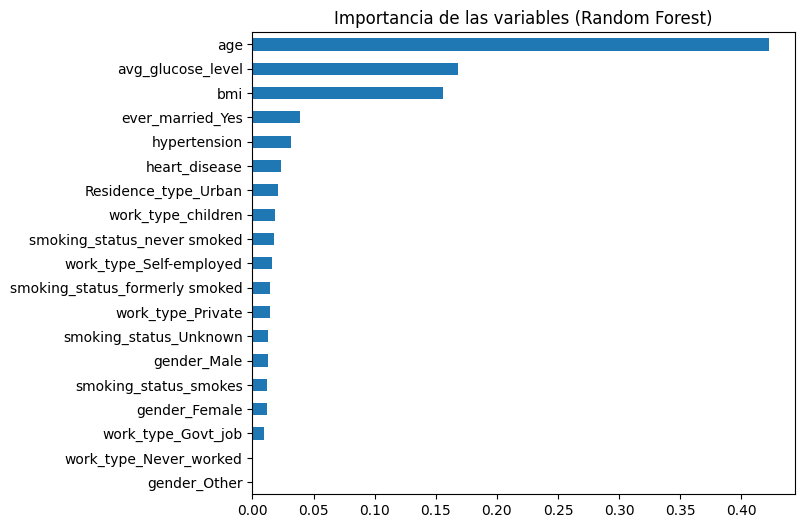

In [22]:
# 3) Importancia de las variables según un Random Forest
from sklearn.ensemble import RandomForestClassifier

X_imp = data_num.drop("stroke", axis=1)
y_imp = data_num["stroke"]

rf_imp = RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                class_weight="balanced", random_state=42)
rf_imp.fit(X_imp, y_imp)

importancia = pd.Series(rf_imp.feature_importances_, index=X_imp.columns).sort_values()

importancia.plot.barh(figsize=(7, 6), title="Importancia de las variables (Random Forest)")
plt.show()

### Variables que se usan en el proyecto
- **Se eliminan:** `gender` y `Residence_type` (casi no se relacionan con el ACV).
- **Se dejan:** edad, hipertensión, enfermedad cardíaca, casado, tipo de trabajo, glucosa promedio, IMC y estado de fumador.
- La **edad** es la variable más importante, seguida de la glucosa y el IMC. El `bmi` se deja porque, aunque su correlación es baja, el modelo lo usa bastante.

In [23]:
datos1 = datos1.drop(['gender', 'Residence_type'], axis=1)
datos1.head()

,age,hypertension,heart_disease,ever_married,work_type,avg_glucose_level,bmi,smoking_status,stroke
0,67.0,0,1,Yes,Private,228.69,36.6,formerly smoked,1
1,61.0,0,0,Yes,Self-employed,202.21,28.1,never smoked,1
2,80.0,0,1,Yes,Private,105.92,32.5,never smoked,1
3,49.0,0,0,Yes,Private,171.23,34.4,smokes,1
4,79.0,1,0,Yes,Self-employed,174.12,24.0,never smoked,1


# **Balance de la variable objetivo**

stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.1
1     4.9
Name: proportion, dtype: float64


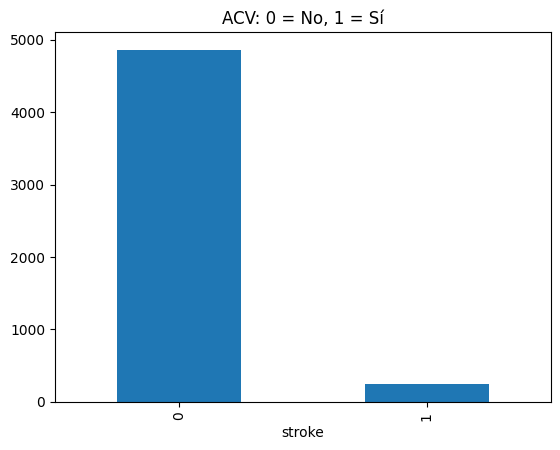

In [24]:
print(datos1["stroke"].value_counts())
print(datos1["stroke"].value_counts(normalize=True).round(3) * 100)
datos1["stroke"].value_counts().plot(kind="bar", title="ACV: 0 = No, 1 = Sí")
plt.show()

Solo el 5% de las personas tuvo ACV, o sea que los datos están muy desbalanceados.
Si no se hace nada, los modelos aprenden a decir "no tendrá ACV" casi siempre.

**Solución:** SMOTENC, que crea casos nuevos parecidos a los de ACV. Una diferencia con la práctica anterior:
ahora el balanceo se hace **solo con los datos de entrenamiento** y dentro de la validación cruzada. Así los datos de prueba son reales y las métricas son honestas
(antes se balanceaba todo junto y se podían colar casos inventados al test, lo que infla los resultados).

# **PARTE 2 - MODELOS PREDICTIVOS Y VALIDACIÓN CRUZADA**

# **Preparación de los datos**

In [26]:
data_with_dummies = pd.get_dummies(datos1, columns=['ever_married'], drop_first=True, dtype=int)
data_with_dummies = pd.get_dummies(data_with_dummies, columns=['work_type', 'smoking_status'],
                                   drop_first=False, dtype=int)

X = data_with_dummies.drop('stroke', axis=1)
y = data_with_dummies['stroke']
variables = X.columns.tolist()

print(X.shape)
X.head()

(5110, 15)


,age,hypertension,heart_disease,avg_glucose_level,bmi,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,0,0,1,0,0,0,1,0,0
1,61.0,0,0,202.21,28.1,1,0,0,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.5,1,0,0,1,0,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,0,0,1,0,0,0,0,0,1
4,79.0,1,0,174.12,24.0,1,0,0,0,1,0,0,0,1,0


## **División 70/30**

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Entrenamiento:", X_train.shape, "| ACV:", y_train.sum())
print("Prueba:       ", X_test.shape, "| ACV:", y_test.sum())

Entrenamiento: (3577, 15) | ACV: 174
Prueba:        (1533, 15) | ACV: 75


## **Cómo se arma cada modelo**
Todos los modelos pasan por los mismos pasos, para que la comparación sea justa:
1. **SMOTENC:** balancea los datos (solo en entrenamiento).
2. **MinMaxScaler:** pone edad, glucosa e IMC en la misma escala (0 a 1).
3. **El modelo.**

In [32]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

columnas_numericas = ['age', 'avg_glucose_level', 'bmi']
# SMOTENC necesita saber cuáles columnas son de tipo categoría (0/1)
posiciones_cat = [i for i, c in enumerate(X.columns) if c not in columnas_numericas]

def armar_pipeline(modelo):
    return Pipeline([
        ('balanceo', SMOTENC(categorical_features=posiciones_cat, k_neighbors=2, random_state=42)),
        ('escalado', ColumnTransformer([('num', MinMaxScaler(), columnas_numericas)],
                                       remainder='passthrough')),
        ('modelo', modelo)
    ])

## **Cómo se evalúa**
- **Validación cruzada (5 partes):** los datos de entrenamiento se dividen en 5. Se entrena con 4 y se prueba con 1, y se repite 5 veces. Así vemos si el modelo funciona siempre y no por suerte.
- **Entrenamiento vs validación:** comparamos el resultado en los datos que el modelo vio contra los que no vio. Si le va mucho mejor en los que vio, está **memorizando (overfitting)**. Si le va mal en los dos, **no está aprendiendo lo suficiente (underfitting)**.
- **Prueba (30%):** al final, datos que el modelo nunca vio.

**Métricas** (siempre mirando la clase "tuvo ACV"):
- **Recall:** de las personas que sí tuvieron ACV, cuántas detectamos. En salud es la más importante.
- **Precisión:** de las que dijimos que tendrían ACV, cuántas acertamos.
- **F1:** equilibrio entre recall y precisión.
- **AUC:** qué tan bien separa a quienes tienen ACV de quienes no (1 es perfecto, 0.5 es azar).

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}   # aquí se guardan los números de cada modelo
modelos = {}      # aquí se guardan los modelos ya entrenados

def evaluar(nombre, modelo):
    pipe = armar_pipeline(modelo)

    # 1) Validación cruzada (con resultado en entrenamiento y en validación)
    cvr = cross_validate(pipe, X_train, y_train, cv=cv, n_jobs=-1, return_train_score=True,
                         scoring={'recall': 'recall', 'f1': 'f1', 'auc': 'roc_auc'})

    # 2) Entrenar con el 70% y probar con el 30%
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    r = {
        'CV F1 entren.': cvr['train_f1'].mean(),   'CV F1 valid.': cvr['test_f1'].mean(),
        'CV AUC entren.': cvr['train_auc'].mean(), 'CV AUC valid.': cvr['test_auc'].mean(),
        'CV Recall valid.': cvr['test_recall'].mean(),
        'Test Exactitud': accuracy_score(y_test, pred),
        'Test Precisión': precision_score(y_test, pred),
        'Test Recall': recall_score(y_test, pred),
        'Test F1': f1_score(y_test, pred),
        'Test AUC': roc_auc_score(y_test, prob),
    }
    resultados[nombre] = r
    modelos[nombre] = pipe

    print(f"=== {nombre} ===")
    print(f"Validación cruzada  -> F1: entrenamiento {r['CV F1 entren.']:.2f} | validación {r['CV F1 valid.']:.2f}"
          f"   |   AUC: entrenamiento {r['CV AUC entren.']:.2f} | validación {r['CV AUC valid.']:.2f}")
    print(f"Prueba (30%)        -> Recall {r['Test Recall']:.2f} | Precisión {r['Test Precisión']:.2f} | "
          f"F1 {r['Test F1']:.2f} | AUC {r['Test AUC']:.2f} | Exactitud {r['Test Exactitud']:.2f}")

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=['No ACV', 'ACV']).plot(ax=axs[0], colorbar=False)
    axs[0].set_title("Matriz de confusión (prueba)")
    RocCurveDisplay.from_predictions(y_test, prob, ax=axs[1])
    axs[1].set_title("Curva ROC (prueba)")
    plt.tight_layout()
    plt.show()

# **ÁRBOL DE DECISIÓN**
**Objetivo:** hacer preguntas de sí/no (¿edad mayor a X?, ¿glucosa alta?) hasta llegar a una decisión. Se entiende fácil y muestra qué variables pesan.

**Configuración:** máximo 10 niveles de preguntas y mínimo 50 personas por hoja, para que no memorice los datos.

=== Árbol ===
Validación cruzada  -> F1: entrenamiento 0.28 | validación 0.22   |   AUC: entrenamiento 0.88 | validación 0.80
Prueba (30%)        -> Recall 0.61 | Precisión 0.13 | F1 0.22 | AUC 0.79 | Exactitud 0.78


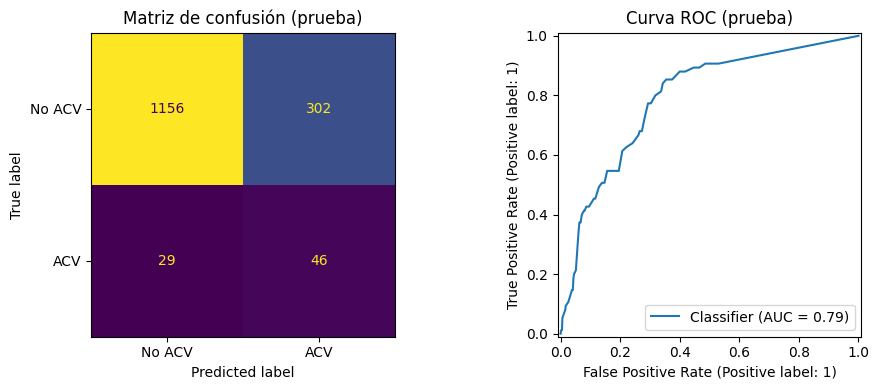

In [34]:
from sklearn.tree import DecisionTreeClassifier
evaluar("Árbol", DecisionTreeClassifier(criterion='gini', min_samples_leaf=50, max_depth=10, random_state=42))

# **KNN**
**Objetivo:** mirar a las personas más parecidas y copiar lo que les pasó.

**Configuración:** k=1 (solo el vecino más cercano) y distancia euclidiana. Los datos van escalados para que edad y glucosa pesen parecido.

=== KNN ===
Validación cruzada  -> F1: entrenamiento 1.00 | validación 0.14   |   AUC: entrenamiento 1.00 | validación 0.57
Prueba (30%)        -> Recall 0.41 | Precisión 0.16 | F1 0.23 | AUC 0.65 | Exactitud 0.86


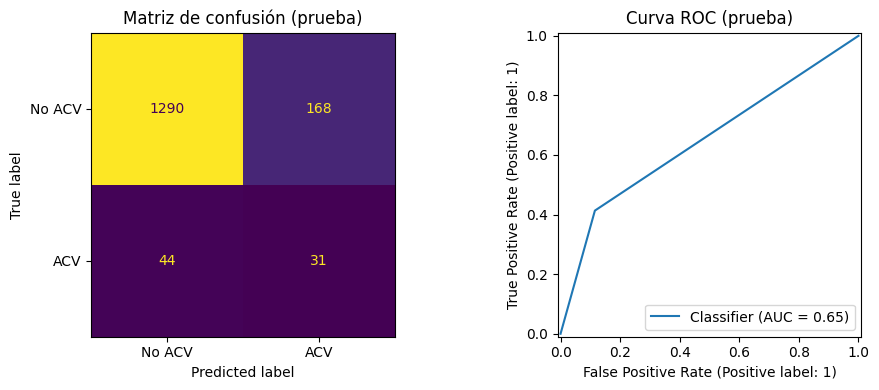

In [35]:
from sklearn.neighbors import KNeighborsClassifier
evaluar("KNN", KNeighborsClassifier(n_neighbors=1, metric='euclidean'))

# **RED NEURONAL**
**Objetivo:** aprender combinaciones entre las variables (por ejemplo, edad alta junto con glucosa alta).

**Configuración:** 2 capas ocultas (10 y 5 neuronas), activación logística, velocidad de aprendizaje 0.02 y hasta 400 vueltas.

=== Red neuronal ===
Validación cruzada  -> F1: entrenamiento 0.29 | validación 0.20   |   AUC: entrenamiento 0.88 | validación 0.77
Prueba (30%)        -> Recall 0.61 | Precisión 0.13 | F1 0.22 | AUC 0.80 | Exactitud 0.79


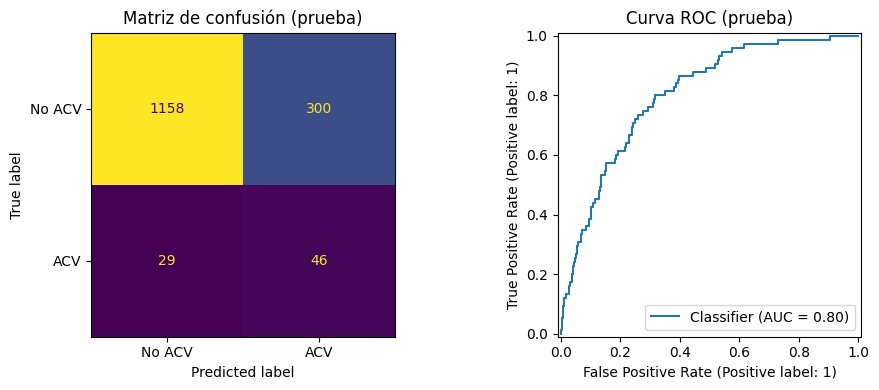

In [36]:
from sklearn.neural_network import MLPClassifier
evaluar("Red neuronal", MLPClassifier(activation="logistic", hidden_layer_sizes=(10, 5), learning_rate='constant',
                                      learning_rate_init=0.02, momentum=0.04, max_iter=400, random_state=4))

# **SVM**
**Objetivo:** encontrar la mejor "frontera" que separa a quienes tuvieron ACV de quienes no.

**Configuración:** kernel rbf (frontera curva), C=1 y probabilidades activadas para poder calcular el AUC.

=== SVM ===
Validación cruzada  -> F1: entrenamiento 0.27 | validación 0.19   |   AUC: entrenamiento 0.85 | validación 0.77
Prueba (30%)        -> Recall 0.61 | Precisión 0.13 | F1 0.21 | AUC 0.79 | Exactitud 0.77


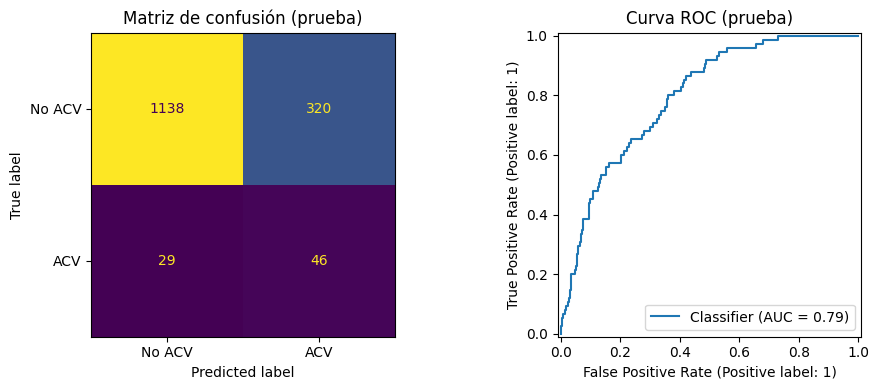

In [37]:
from sklearn.svm import SVC
evaluar("SVM", SVC(kernel='rbf', C=1, class_weight="balanced", probability=True, random_state=42))

# **RANDOM FOREST**
**Objetivo:** muchos árboles votando juntos. Es más estable que un solo árbol.

**Configuración:** 150 árboles, profundidad máxima 20, mínimo 10 personas por hoja y cada árbol usa el 90% de los datos.

=== Random Forest ===
Validación cruzada  -> F1: entrenamiento 0.36 | validación 0.24   |   AUC: entrenamiento 0.94 | validación 0.82
Prueba (30%)        -> Recall 0.65 | Precisión 0.16 | F1 0.26 | AUC 0.83 | Exactitud 0.81


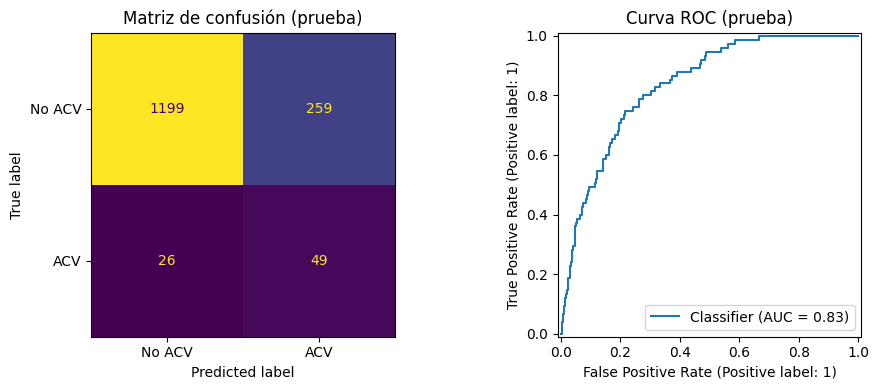

In [38]:
evaluar("Random Forest", RandomForestClassifier(n_estimators=150, max_samples=0.9, criterion='gini',
                                                max_depth=20, min_samples_leaf=10, random_state=42))

# **XGBOOST**
**Objetivo:** árboles pequeños que se van corrigiendo unos a otros, cada uno arregla los errores del anterior.

**Configuración:** 150 árboles, profundidad 5 y velocidad de aprendizaje 0.1.

=== XGBoost ===
Validación cruzada  -> F1: entrenamiento 0.55 | validación 0.16   |   AUC: entrenamiento 0.97 | validación 0.78
Prueba (30%)        -> Recall 0.37 | Precisión 0.18 | F1 0.24 | AUC 0.79 | Exactitud 0.89


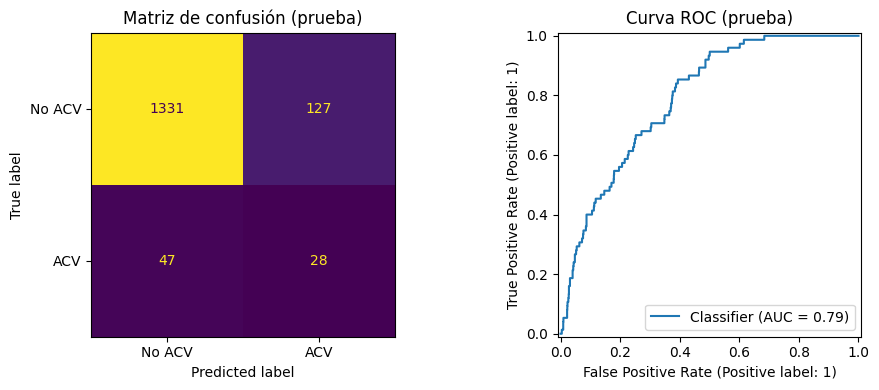

In [39]:
from xgboost import XGBClassifier
evaluar("XGBoost", XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42))

# **Comparación de los modelos**

In [40]:
tabla = pd.DataFrame(resultados).T.sort_values('CV F1 valid.', ascending=False)
tabla.round(3)

,CV F1 entren.,CV F1 valid.,CV AUC entren.,CV AUC valid.,CV Recall valid.,Test Exactitud,Test Precisión,Test Recall,Test F1,Test AUC
Random Forest,0.358,0.241,0.939,0.818,0.638,0.814,0.159,0.653,0.256,0.834
Árbol,0.280,0.221,0.882,0.795,0.633,0.784,0.132,0.613,0.217,0.790
Red neuronal,0.293,0.202,0.877,0.774,0.506,0.785,0.133,0.613,0.219,0.801
SVM,0.265,0.191,0.853,0.768,0.541,0.772,0.126,0.613,0.209,0.795
XGBoost,0.552,0.155,0.969,0.780,0.247,0.886,0.181,0.373,0.243,0.790
KNN,1.000,0.143,1.000,0.566,0.247,0.862,0.156,0.413,0.226,0.649


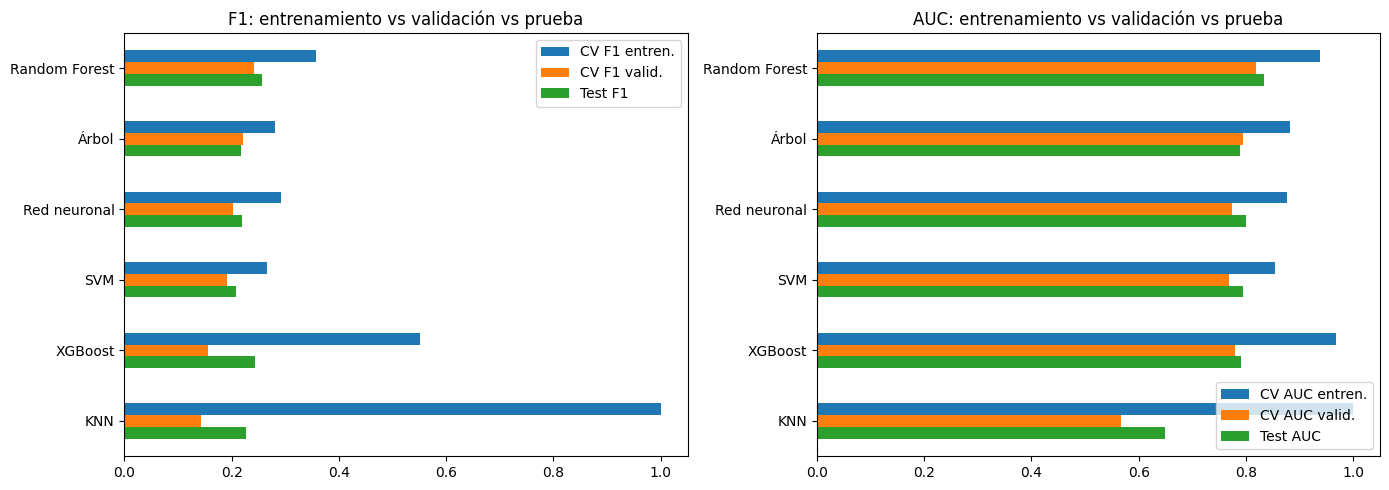

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

tabla[['CV F1 entren.', 'CV F1 valid.', 'Test F1']].plot.barh(ax=axs[0])
axs[0].set_title("F1: entrenamiento vs validación vs prueba")
axs[0].invert_yaxis()

tabla[['CV AUC entren.', 'CV AUC valid.', 'Test AUC']].plot.barh(ax=axs[1])
axs[1].set_title("AUC: entrenamiento vs validación vs prueba")
axs[1].invert_yaxis()

plt.tight_layout()
plt.show()

## **Revisión de overfitting y underfitting**

Se compara el AUC en entrenamiento contra el AUC en validación:
- Diferencia **mayor a 0.10:** el modelo memoriza (**overfitting**).
- AUC de validación **menor a 0.70:** el modelo no aprende lo suficiente (**underfitting**).
- Si no pasa ninguna de las dos: el ajuste es **adecuado**.

In [42]:
diag = []
for nombre, r in resultados.items():
    brecha = r['CV AUC entren.'] - r['CV AUC valid.']
    if brecha > 0.10:
        estado = "Overfitting (memoriza)"
    elif r['CV AUC valid.'] < 0.70:
        estado = "Underfitting (aprende poco)"
    else:
        estado = "Ajuste adecuado"
    diag.append([nombre, round(r['CV AUC entren.'], 2), round(r['CV AUC valid.'], 2), round(brecha, 2), estado])

pd.DataFrame(diag, columns=['Modelo', 'AUC entren.', 'AUC valid.', 'Diferencia', 'Diagnóstico']).set_index('Modelo')

,AUC entren.,AUC valid.,Diferencia,Diagnóstico
Modelo,,,,
Árbol,0.88,0.80,0.09,Ajuste adecuado
KNN,1.00,0.57,0.43,Overfitting (memoriza)
Red neuronal,0.88,0.77,0.10,Overfitting (memoriza)
SVM,0.85,0.77,0.09,Ajuste adecuado
Random Forest,0.94,0.82,0.12,Overfitting (memoriza)
XGBoost,0.97,0.78,0.19,Overfitting (memoriza)


## **Conclusión sobre la calidad de los modelos**

In [43]:
mejor = tabla.index[0]
print("Mejor modelo según la validación cruzada (F1):", mejor)
print(f"  F1 validación: {tabla.loc[mejor, 'CV F1 valid.']:.2f} | Recall en prueba: {tabla.loc[mejor, 'Test Recall']:.2f} | AUC en prueba: {tabla.loc[mejor, 'Test AUC']:.2f}")
print("\nMayor recall en prueba (detecta más casos de ACV):", tabla['Test Recall'].idxmax(), f"({tabla['Test Recall'].max():.2f})")
print("Mayor AUC en prueba:", tabla['Test AUC'].idxmax(), f"({tabla['Test AUC'].max():.2f})")

Mejor modelo según la validación cruzada (F1): Random Forest
  F1 validación: 0.24 | Recall en prueba: 0.65 | AUC en prueba: 0.83

Mayor recall en prueba (detecta más casos de ACV): Random Forest (0.65)
Mayor AUC en prueba: Random Forest (0.83)


### Conclusión (Parte 2)
- **Mejor modelo: Random Forest.** Es el que mejor F1 saca en la validación cruzada y también el mejor en prueba (recall 0.65 y AUC 0.83).
- **KNN con k=1 es el peor:** memoriza por completo (F1 de 1.00 en entrenamiento contra 0.14 en validación). Con un solo vecino copia hasta el ruido.
- **Random Forest, XGBoost y Red neuronal** tienen sobreajuste leve o moderado: les va mejor en lo que vieron que en lo nuevo. XGBoost es el que más (AUC de 0.97 contra 0.77).
- **Árbol y SVM** tienen un ajuste adecuado, pero su desempeño es medio (AUC cercano a 0.8).
- **Ningún modelo tiene underfitting:** todos aprenden algo útil (AUC de validación sobre 0.75, menos KNN).
- **Calidad general:** los modelos sirven como alerta, no como diagnóstico. El mejor detecta cerca de 2 de cada 3 personas con ACV (recall 0.65), pero con muchas falsas alarmas (precisión 0.16, solo 16 de cada 100 alertas son ACV reales).
  Esto pasa porque hay muy pocos casos de ACV (5%) y los datos tienen pocas variables.
- **Ojo con la práctica anterior:** allá daban 0.91 a 0.93 de exactitud porque los casos inventados por SMOTENC se colaban al test. Aquí el test es real, por eso los números son más bajos pero más honestos.

# **PARTE 3 - GRIDSEARCH Y MODELO FINAL**

El mejor modelo (según la validación cruzada) se mejora con **GridSearch**: se prueban varias combinaciones de configuración y se queda la mejor.
Se usa validación cruzada de 5 partes y el **F1** para elegir, y solo con los datos de entrenamiento (la prueba del 30% no se toca hasta el final).

In [44]:
from sklearn.model_selection import GridSearchCV

# Combinaciones a probar para cada modelo
grillas = {
    "Árbol": (DecisionTreeClassifier(random_state=42),
              {'modelo__max_depth': [3, 5, 10], 'modelo__min_samples_leaf': [10, 30, 50]}),
    "KNN": (KNeighborsClassifier(),
            {'modelo__n_neighbors': [1, 3, 5, 11, 21], 'modelo__weights': ['uniform', 'distance']}),
    "Red neuronal": (MLPClassifier(activation="logistic", max_iter=400, random_state=4),
                     {'modelo__hidden_layer_sizes': [(10, 5), (20, 10)], 'modelo__learning_rate_init': [0.01, 0.02]}),
    "SVM": (SVC(kernel='rbf', probability=True, random_state=42),
            {'modelo__C': [0.5, 1, 5], 'modelo__gamma': ['scale', 0.1]}),
    "Random Forest": (RandomForestClassifier(max_samples=0.9, random_state=42),
                      {'modelo__n_estimators': [100, 150, 200], 'modelo__max_depth': [5, 10, 20], 'modelo__min_samples_leaf': [5, 10]}),
    "XGBoost": (XGBClassifier(random_state=42),
                {'modelo__n_estimators': [100, 150, 200], 'modelo__max_depth': [3, 5], 'modelo__learning_rate': [0.05, 0.1]}),
}

print("Modelo que se va a mejorar:", mejor)
modelo_base, parametros = grillas[mejor]

gs = GridSearchCV(armar_pipeline(modelo_base), parametros, cv=cv, scoring='f1', n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

print("\nMejor configuración:", gs.best_params_)
print(f"F1 en validación cruzada: {gs.best_score_:.3f}  (antes: {tabla.loc[mejor, 'CV F1 valid.']:.3f})")

Modelo que se va a mejorar: Random Forest

Mejor configuración: {'modelo__max_depth': 20, 'modelo__min_samples_leaf': 10, 'modelo__n_estimators': 150}
F1 en validación cruzada: 0.241  (antes: 0.241)


In [45]:
# Prueba con el 30%
modelo_gs = gs.best_estimator_
pred_gs = modelo_gs.predict(X_test)
prob_gs = modelo_gs.predict_proba(X_test)[:, 1]

comparacion = pd.DataFrame({
    'Antes del GridSearch': [resultados[mejor]['Test Recall'], resultados[mejor]['Test Precisión'],
                           resultados[mejor]['Test F1'], resultados[mejor]['Test AUC']],
    'Después del GridSearch': [recall_score(y_test, pred_gs), precision_score(y_test, pred_gs),
                             f1_score(y_test, pred_gs), roc_auc_score(y_test, prob_gs)]
}, index=['Recall', 'Precisión', 'F1', 'AUC'])
comparacion.round(3)

,Antes del GridSearch,Después del GridSearch
Recall,0.653,0.653
Precisión,0.159,0.159
F1,0.256,0.256
AUC,0.834,0.834


              precision    recall  f1-score   support

      No ACV       0.98      0.82      0.89      1458
         ACV       0.16      0.65      0.26        75

    accuracy                           0.81      1533
   macro avg       0.57      0.74      0.57      1533
weighted avg       0.94      0.81      0.86      1533



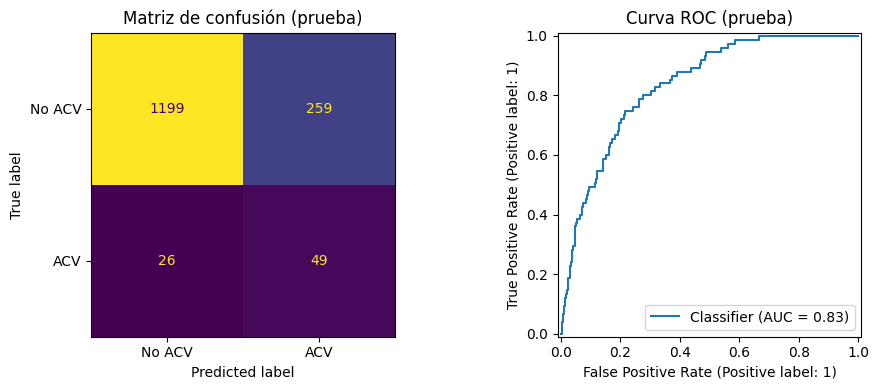

In [46]:
print(classification_report(y_test, pred_gs, target_names=['No ACV', 'ACV']))

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_gs), display_labels=['No ACV', 'ACV']).plot(ax=axs[0], colorbar=False)
axs[0].set_title("Matriz de confusión (prueba)")
RocCurveDisplay.from_predictions(y_test, prob_gs, ax=axs[1])
axs[1].set_title("Curva ROC (prueba)")
plt.tight_layout()
plt.show()

### Conclusión (Parte 3)
- Se mejoró el **Random Forest**. GridSearch eligió 150 árboles, profundidad 20 y mínimo 10 personas por hoja, que **es la misma configuración que ya teníamos**. Es decir, la configuración inicial ya era la mejor de las probadas y el límite está en los datos, no en el ajuste del modelo.
- En la prueba, el modelo detecta cerca de 2 de cada 3 personas con ACV (recall 0.65), con un AUC de 0.83 (separa bien a quien tiene ACV de quien no).
- La precisión sigue baja (0.16): da varias falsas alarmas. Para un caso de salud es preferible eso a dejar pasar un ACV, pero el resultado se debe usar como apoyo y no como diagnóstico.

# **Modelo final**

Con la mejor configuración ya definida, el modelo se entrena otra vez con **todos los datos (100%)** y se guarda para el despliegue.
El archivo guarda el modelo completo (balanceo + escalado + modelo) y la lista de variables, así que en el despliegue no hace falta cargar un scaler aparte.

In [47]:
from sklearn.base import clone

modelo_final = clone(gs.best_estimator_)
modelo_final.fit(X, y)   # 100% de los datos

with open('modelo_final.pkl', 'wb') as f:
    pickle.dump([modelo_final, variables], f)

print("Modelo guardado en modelo_final.pkl")
print("Variables que espera el modelo:", variables)

Modelo guardado en modelo_final.pkl
Variables que espera el modelo: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [48]:
# Prueba rápida: se carga el archivo y se predicen unas filas
with open('modelo_final.pkl', 'rb') as f:
    modelo_cargado, variables_cargadas = pickle.load(f)

print(modelo_cargado.predict(X[variables_cargadas].head(5)))

[1 1 1 0 1]
